In [31]:
# https://climexp.knmi.nl/ERA5/era5_t2m_daily.nc
# https://climexp.knmi.nl/ERA5/era5_msl_daily.nc
# https://climexp.knmi.nl/ERA5/era5_z500_daily.nc 

In [ ]:

from c3s_event_attribution_tools import analogue_functions_C3S as my 

from c3s_event_attribution_tools import *
import geopandas as gpd
from datetime import datetime, timedelta

import xarray as xr
import os
import subprocess
import numpy as np
import iris
import calendar
import matplotlib.pyplot as plt
import matplotlib
import cartopy.crs as ccrs
import cartopy as cart
import cartopy.feature as cf
import glob
from iris.util import equalise_attributes
from iris.util import unify_time_units
import scipy.stats as stats


In [33]:
# Defining the variables:

date = [2023, 'Mar', 11] 
impact_domain = [-32, -36, -56, -61]  # Impact region, [NORTH, SOUTH, WEST, EAST] 
Haz = 't2m' 
z500_domain = [-20, -55, -30, -70] 
slp_domain = [-25, -55, -35, -80] 



In [34]:
### Automated variables - can be adjusted for sensitivity testing

# months to include, automatically three calendar month window around the event
month = date[1]
X = list(calendar.month_abbr)
i=X.index(month)
if 1<i<12:
    months = [X[i-1], X[i], X[i+1]]
elif i == 1:
    months = [X[12], X[i], X[i+1]]
elif i ==12:
    months = [X[i-1], X[i], X[1]]

# Or use this line to manually select different month set (can be full year)
#months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

R1 = [90, -90, 0, -180]  # Assess correlation globally
Y1 = 1950; Y2 = 2025 # Use years 1950-2025 (most available)

# number of analogues to use - set at 1% (assuming 30 day months) of timeslice 1 days 
N = int(((Y2-Y1)*len(months)*30)/100)
# Or use this line to manually select N
# N = 30

In [35]:
### Get event fields
# Check if using ERA5 or extended forecast (for when ERA5 not yet available)
event_data = 'era5'
my.ERA5FILESUFFIX = "_daily"

# Initially using ERA5 daily data, if that gives no data switch to extended:
if my.reanalysis_data_single_date(Haz, date)==None:
    my.ERA5FILESUFFIX = "_daily_extended"
    event_data = "extended"
    print('ERA5 data not yet available, using ECMWF extended forecast for event data')

# If extended also not available give error message:
if my.reanalysis_data_single_date(Haz, date)==None:
    print('Data is not available for that date, please select a date between 1 Jan 1950 and the present day')
    quit() ## If the date has not data (ERA5 or extended) then stop here, and print message above

# Check what it is using:
my.ERA5FILESUFFIX

event_Haz = my.reanalysis_data_single_date(Haz, date)
event_msl = my.reanalysis_data_single_date('msl', date)
event_z500 = my.reanalysis_data_single_date('z500', date)

Read file: era5_t2m_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


Read file: era5_t2m_daily.nc for date [2023, 'Mar', 11]
Read file: era5_t2m_daily.nc for date [2023, 'Mar', 11]
Read file: era5_msl_daily.nc for date [2023, 'Mar', 11]
Read file: era5_z500_daily.nc for date [2023, 'Mar', 11]


In [36]:
event_msl

<iris 'Cube' of air_pressure_at_sea_level / (Pa) (latitude: 360; longitude: 720)>

In [37]:
### Lists of analogues for all combination
dates_slp = my.anomaly_period_outputs(Y1, Y2, 'msl', N, date, months, slp_domain)
dates_z500 = my.anomaly_period_outputs(Y1, Y2, 'z500', N, date, months, z500_domain)


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4386: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2194: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2194: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using l

Read file: era5_msl_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4386: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2194: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2194: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning:

Read file: era5_z500_daily.nc for date [2023, 'Mar', 11]


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4386: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2194: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/coords.py:2194: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning:

In [38]:
# Calculate the Impact Index for all analogue dates and the event
II_event = my.impact_index(event_Haz, impact_domain)

impact_cube = my.reanalysis_data(Haz, Y1, Y2, months)
II_z500 = []
daily_analogues = my.analogues_list(impact_cube, dates_z500)  
for each in daily_analogues:
    II_z500.append(my.impact_index(each, impact_domain))

II_msl = []
daily_analogues = my.analogues_list(impact_cube, dates_slp)  
for each in daily_analogues:
    II_msl.append(my.impact_index(each, impact_domain))


/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:435: IrisDefaultingWarning: Using DEFAULT_SPHERICAL_EARTH_RADIUS.
  warnings.warn(


In [39]:
impact_cube

Near-Surface Air Temperature (K),time,latitude,longitude
Shape,6694,360,720
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x
Auxiliary coordinates,,,
day_of_month,x,-,-
month,x,-,-
year,x,-,-
Attributes,,,


In [40]:
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

start_period = datetime(2025, 11, 1)
end_period = datetime(2025, 11, 11)
parameter = 'Tmean'
impact_domain = [-32, -36, -56, -61]  # Impact region, [NORTH, SOUTH, WEST, EAST] 

bbox = (impact_domain[3], impact_domain[1], impact_domain[2], impact_domain[0])

# daily variable data
gr_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter=parameter, bbox=bbox, time_range=(start_period, end_period), to_unit="c")
# daily z500 data
z500_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter="z500", bbox=bbox, time_range=(start_period, end_period), to_unit="c")
# daily slp data
slp_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter="slp", bbox=bbox, time_range=(start_period, end_period), to_unit="c")

Connected to: https://beacon-era5.maris.nl/ server successfully
Connected to: https://beacon-era5.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (299.0, -36, 304.0, -32)
Running query: {"from": "era5_daily_mean_2m_temperature", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 299.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 304.0}, {"column": "latitude", "gt_eq": -36, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": -32}]}, {"column": "valid_time", "gt_eq": "2025-11-01T00:00:00.000000", "lt_eq": "2025-11-11T00:00:00.000000"}], "output": {"format": "parquet"}}


Exception: Query returned no content

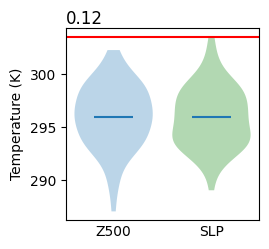

In [ ]:
# Violin Plot (to visually check the result)
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(2.5, 2.5))
plots = axs.violinplot([II_z500, II_msl], showmeans=True, showextrema=False, widths = .8)
plots["bodies"][1].set_facecolor('green')
axs.axhline(II_event, color='r', label = 'Event')
axs.set_xticks([1,2], labels=['Z500', 'SLP'])
axs.tick_params(axis='x', length=0)
axs.set_ylabel('Temperature (K)')
t, p = stats.ttest_ind(II_z500, II_msl, equal_var=False, alternative='two-sided')
if p < 0.05:
    axs.set_title(('%.2f'%t), pad=-20, loc='left', fontweight="bold")
else:
    axs.set_title(('%.2f'%t), pad=-20, loc='left')

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 0, '# of analogues')

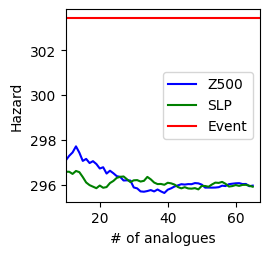

In [ ]:
# Shown for larger range of analogue proportions
meanT = []
for i in np.arange(len(II_z500)):
    meanT.append(np.mean(II_z500[:i]))

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(2.5, 2.5))
axs.plot(meanT, 'b', label = 'Z500')

meanT = []
for i in np.arange(len(II_msl)):
    meanT.append(np.mean(II_msl[:i]))

axs.plot(meanT, 'g', label = 'SLP')
axs.set_xlim([10, N])
axs.axhline(II_event, color='r', label = 'Event')
axs.legend() 
axs.set_ylabel('Hazard')
axs.set_xlabel('# of analogues')

In [ ]:
# Summary print out
print('Summary: identify circulation variable')
print('Event definition:')
print('     Date: ', date)
print('     Hazard: ', Haz)
print('     Impact domain: ', impact_domain)
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Z500 domain:', z500_domain)
print('     MSL domain:', slp_domain)
print('Results:')

u, p = stats.ttest_ind(II_z500, II_msl, equal_var=False, alternative='two-sided')
if np.mean(II_z500) > np.mean(II_msl):
    print('Recommend using Z500')
else:
    print('Recommend using SLP')

if p < 0.05:
    print('  Statistically significant difference')
else:
    print('  Difference is not statistically significant')


Summary: identify circulation variable
Event definition:
     Date:  [2023, 'Mar', 11]
     Hazard:  t2m
     Impact domain:  [-32, -36, -56, -61]
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  67
     Z500 domain: [-20, -55, -30, -70]
     MSL domain: [-25, -55, -35, -80]
Results:
Recommend using Z500
  Difference is not statistically significant


In [ ]:
dates_slp

['19530218',
 '20210407',
 '19520302',
 '19960311',
 '19630316',
 '19690413',
 '19560224',
 '19760214',
 '19820424',
 '19600326',
 '20100331',
 '19750421',
 '19640226',
 '19530316',
 '19840409',
 '19540417',
 '20020405',
 '19680225',
 '20030224',
 '19500216',
 '20080315',
 '19570324',
 '19680219',
 '20120304',
 '19870227',
 '20120203',
 '19880325',
 '19890320',
 '19720402',
 '19990304',
 '19570221',
 '19810206',
 '20040331',
 '20240206',
 '19580410',
 '20220418',
 '19830410',
 '19570307',
 '19800407',
 '19750209',
 '20180421',
 '19860409',
 '19930429',
 '20050303',
 '20110308',
 '19750406',
 '20110302',
 '19740308',
 '19910415',
 '20230211',
 '20040305',
 '20070416',
 '20230306',
 '20200203',
 '19720321',
 '20000201',
 '19960411',
 '19580426',
 '19550324',
 '20180216',
 '20180328',
 '19500223',
 '20020303',
 '20140304',
 '19610214',
 '20130421']